# Inference in ODE-Driven (Deterministic) Dynamical Systems

As discucsed briefly in the introduction, `dynestyx` also supports inference in deterministic dynamical systems, such as those generated via an ordinary differential equation (ODE). In this tutorial, we show how to use the `ODESimulator` to perform Bayesian inference on the parameters of an ODE.

## The System

In this example, we'll use the Lorenz 63 model. The state evolution will be specified as 

$$ \frac{\mathrm{d} x}{\mathrm{d} t} = \left( \begin{bmatrix} -10 & 10 & 0 \\ \rho - x_{t,2} & -1 & 0 \\ x_{t,1} & 0 & \frac{-8}{3} \end{bmatrix} \right) x_{t}$$

where the transition depends on some parameter $\rho$. 

Let's set up a probabilistic program for this dynamical system, putting a uniform $U(10.0, 40.0)$ prior on $\rho$. Our observations will be a noisy version of the first component, $x_{t, 1}$.

## Specifying the Model in `dynestyx`

To specify the model in `dynestyx`, we specify a `ContinuousStateEvolution` that does not include a drift.

In [1]:
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp
from dsx.dynamical_models import DynamicalModel, ContinuousTimeStateEvolution
from dsx.observations import LinearGaussianObservation
import dsx

def continuous_time_deterministic_l63_model(rho=None):
    """Model that samples drift parameter rho and uses it in dynamics (ODE, no diffusion)."""
    rho = numpyro.sample("rho", dist.Uniform(10.0, 40.0), obs=rho)

    # Create the dynamical model with sampled rho
    dynamics = DynamicalModel(
        state_dim=3,
        observation_dim=1,
        control_dim=1,  # Model uses controls, and are ignored when u=None
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(3), covariance_matrix=2.0**2 * jnp.eye(3)
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=lambda x, u, t: jnp.array(
                [
                    10.0 * (x[1] - x[0]),
                    x[0] * (rho - x[2]) - x[1],
                    x[0] * x[1] - (8.0 / 3.0) * x[2],
                ]
            )
            + (10 * u if u is not None else jnp.zeros(3)),
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.array([[1.0, 0.0, 0.0]]), R=jnp.array([[1.0**2]])
        ),
    )

    # Return a sampled dynamical model, named "f".
    return dsx.sample_ds("f", dynamics)

## Generating Samples From the Generative Model

As in our previous examples, we must specify a `dsx.simulators` object to tell `dynestyx` how to generate samples. For determeinistic, continuous-time dynamical systems, we call an `ODESimulator`. This is primarily a frontend for a conventional numerical solver, housed by `diffrax`, coupled with sampling from the observation model.

In [2]:
from dsx.simulators import ODESimulator
from dsx.ops import Trajectory, Context
from dsx.handlers import Condition
import jax.random as jr
from numpyro.infer import Predictive

obs_times = jnp.arange(start=0.0, stop=2.0, step=0.001)
context = Context(observations=Trajectory(times=obs_times))

prng_key = jr.PRNGKey(0)
sde_solver_key, predictive_key = jr.split(prng_key, 2)

predictive_model = Predictive(continuous_time_deterministic_l63_model, num_samples=1)

with ODESimulator():
    with Condition(context=context):
        synthetic_samples = predictive_model(predictive_key, rho=28.0)


We can visualize the resulting dynamical system and observations:

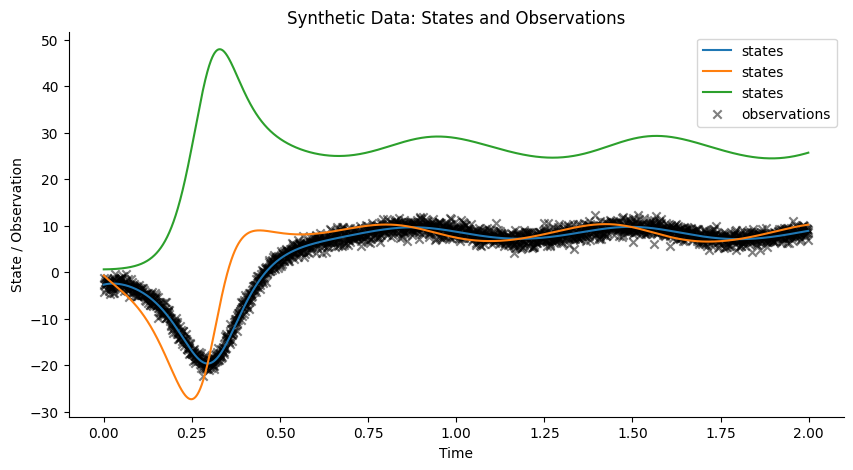

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

plt.plot(synthetic_samples["times"][0], synthetic_samples["states"][0], label="states")
plt.scatter(
    synthetic_samples["times"][0],
    synthetic_samples["observations"][0],
    label="observations",
    marker="x",
    color="black",
    alpha=0.5,
)
plt.title("Synthetic Data: States and Observations")
plt.xlabel("Time")
plt.ylabel("State / Observation")
sns.despine()
plt.legend()
plt.show()

We can also visualize in 3d to see the typical Lorenz attractor shape.

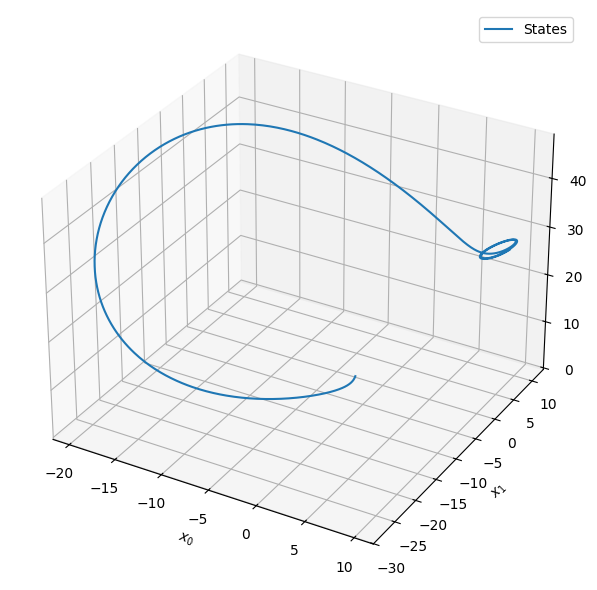

In [4]:
obs = synthetic_samples["observations"][0]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    synthetic_samples["states"][0][:, 0],
    synthetic_samples["states"][0][:, 1],
    synthetic_samples["states"][0][:, 2],
    label="States",
)

ax.set_xlabel("$x_0$")
ax.set_ylabel("$x_1$")
ax.set_zlabel("$x_2$")
ax.legend()
plt.tight_layout()
plt.show()


## Bayesian Inference via Simulation

For a deterministic dynamical system, one option for inference is to deterministically solve the system -- given the initial state and system parameters -- and solve as a conventional probabilistic program. While this is not the most scalable solution for very long or high-dimensional time series (for those, we can use [probabilistic solvers](https://arxiv.org/abs/2110.11812), to be incorporated into `dynestyx` soon), it is reasonable for time series on the order of hundreds of points with moderate dimension, so long as the underlying ODE is relatively well-behaved.

To perform inference via this "unrolling" in `dynestyx`, we simply change the `Context` of teh `DiscreteTimeSimulator` to include observations:

In [5]:
obs_values = synthetic_samples["observations"][0]
observations_trajectory = Trajectory(times=obs_times, values=obs_values)
context = Context(observations=observations_trajectory)

def data_conditioned_model():
    with ODESimulator():
        with Condition(context=context):
            return continuous_time_deterministic_l63_model()
        

The resulting model is directly compatible with `numpyro` inference tools, which will perform joint (parameter, state) inference, for example, using NUTS. The resulting inference will be quite slow -- we are running a numerical solver at every time step, that the inference method must backpropagate through -- but relatively accurate.

In [6]:
from numpyro.infer import MCMC, NUTS
import jax.random as jr

mcmc_key = jr.PRNGKey(42)

nuts_kernel = NUTS(data_conditioned_model)
mcmc = MCMC(nuts_kernel, num_samples=250, num_warmup=250)
mcmc.run(mcmc_key)

posterior_samples = mcmc.get_samples()

sample: 100%|██████████| 500/500 [00:31<00:00, 15.75it/s, 15 steps of size 4.62e-03. acc. prob=0.92] 


The posterior of parameters, such as $\rho$, is thus available:

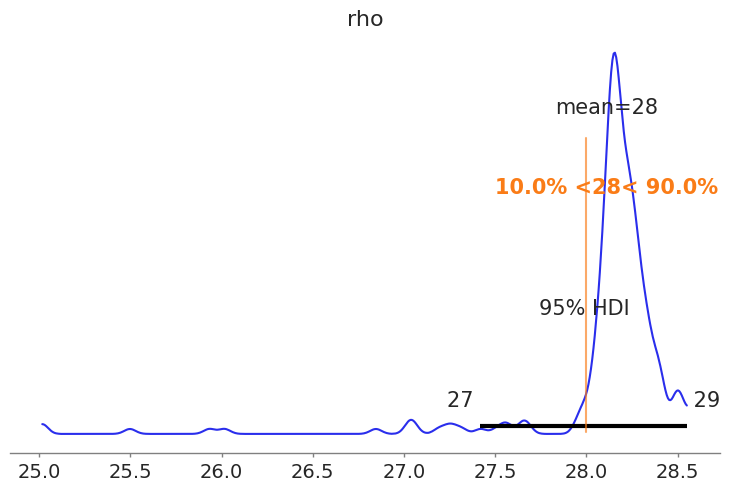

In [7]:
import arviz as az

az.style.use("arviz-white")

# For plotting reasons
parameter_posterior_samples = {"rho": posterior_samples["rho"]}

az.plot_posterior(parameter_posterior_samples, var_names=["rho"], hdi_prob=0.95, ref_val=28.0)

plt.show()


As in the discrete-time inference tutorial, we also once again get smoothing estimates of the underlying states.

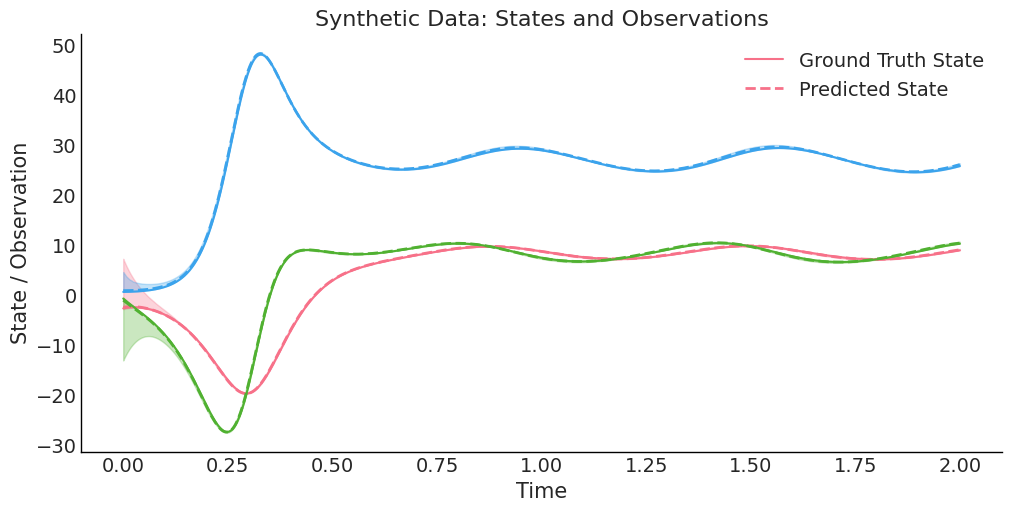

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

times = synthetic_samples["times"][0]
synthetic_states = synthetic_samples["states"][0]
states = posterior_samples["states"]

median = jnp.median(states, axis=0)  # (T, D)
p10 = jnp.percentile(states, 10, axis=0)  # (T, D)
p90 = jnp.percentile(states, 90, axis=0)  # (T, D)
colors = sns.color_palette("husl", 3)

for d in range(3):
    label = "Ground Truth State" if d == 0 else None
    plt.plot(times, synthetic_states[:, d], label=label, color=colors[d])
    plt.fill_between(times, p10[:, d], p90[:, d], alpha=0.3, color=colors[d])
    label = "Predicted State" if d == 0 else None
    plt.plot(times, median[:, d], label=label, lw=2, ls="--", color=colors[d])

plt.title("Synthetic Data: States and Observations")
plt.xlabel("Time")
plt.ylabel("State / Observation")
sns.despine()
plt.legend()
plt.show()
